In [2]:
import pandas as pd

df = pd.read_csv("mall_customers.csv")
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   49                  22                      12
1           2  Female   56                  41                      25
2           3    Male   66                  41                      52
3           4    Male   69                  35                      85
4           5    Male   49                  44                      53


In [3]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,49,22,12
1,2,Female,56,41,25
2,3,Male,66,41,52
3,4,Male,69,35,85
4,5,Male,49,44,53
...,...,...,...,...,...
195,196,Female,47,97,4
196,197,Female,55,125,62
197,198,Female,55,131,65
198,199,Male,62,83,32


In [4]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
import numpy as np

k = 5
np.random.seed(42)

# random centroids
indices = np.random.choice(len(X_scaled), k, replace=False)
centroids = X_scaled[indices]

In [7]:
for _ in range(100):

    # Step 1: Compute distances
    distances = np.linalg.norm(X_scaled[:, None] - centroids, axis=2)

    # Step 2: Assign clusters
    labels = np.argmin(distances, axis=1)

    # Step 3: Update centroids
    new_centroids = np.array([
        X_scaled[labels == i].mean(axis=0) for i in range(k)
    ])

    # Step 4: Check convergence
    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

In [8]:
print(labels[:10])

[4 4 2 2 2 1 4 3 0 2]


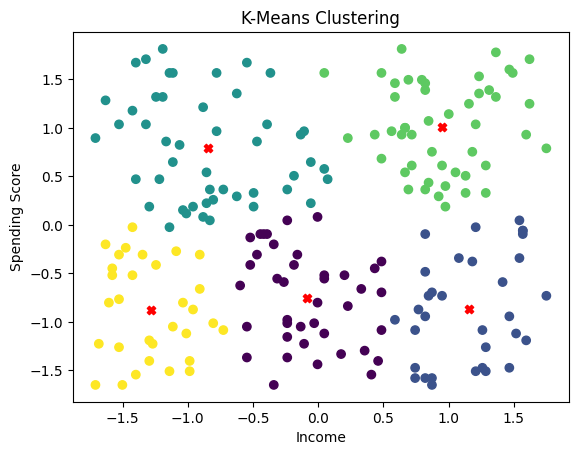

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X')
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

In [10]:
import pickle

with open('cluster_labels.pkl', 'wb') as f:
    pickle.dump(labels, f)

print("Cluster labels saved to 'cluster_labels.pkl'")

Cluster labels saved to 'cluster_labels.pkl'
